# Optuna vs grid search in QBioCode

`grid_search: True` used to mean one thing: fit **every** combination of the values
listed in a `gridsearch_<model>_args` block. The shipped random-forest block is
4x2x4x3x3x2 = **576 combinations**, so at `cross_validation: 5` a single random forest
costs **2,880 fits** — and the sweep is blind, spending as much time in a hopeless
corner as in a promising one.

Tuning now runs through Optuna by default. This notebook measures the difference and
shows what the new config syntax buys you:

1. [Setup](#setup)
2. [The exhaustive grid, timed](#grid) — `tuner: grid`, the old behaviour
3. [Optuna on the same blocks, timed](#optuna) — `tuner: optuna`, the default
4. [Side by side](#compare) — accuracy against wall clock
5. [Ranges, not just lists](#ranges) — what only Optuna can search
6. [Tuning the quantum models](#quantum) — new: `tune_quantum: True`
7. [Takeaways](#takeaways)

Everything here runs on the local simulator. Nothing touches a real device.

> **Kernel.** Pick the kernel whose interpreter is *this checkout's* `.venv`. A
> Jupyter kernel is chosen independently of which checkout you edited, and VS Code
> only auto-discovers a `.venv` at the workspace root -- so a fork or worktree needs
> its kernel registered explicitly:
> ```bash
> .venv/bin/python -m ipykernel install --user --name qbiocode-fork \
>     --display-name "Python (QBioCode fork)"
> ```
> The first cell prints which QBioCode actually answered; check it before reading
> any number below.

<a id="setup"></a>
## 1. Setup

In [1]:
# On macOS a QBioCode process ends up with three LLVM OpenMP runtimes mapped in under
# one install name (torch, qiskit-aer, xgboost). Whichever initialises second dies in
# __kmp_fork_barrier the first time it opens a parallel region -- below Python, so there
# is no traceback and a notebook front end can only report "kernel died".
# This must run BEFORE qbiocode/torch are imported, so keep it in the first cell.
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")

import time
import warnings

import numpy as np
import pandas as pd

warnings.simplefilter("ignore")

import qbiocode
from qbiocode import scale_train_test
from qbiocode.evaluation.model_run import model_run

# Which QBioCode answered? Printed as a path *relative to home* -- the absolute
# install path would be committed into a published page. If this is not the
# checkout you are editing, stop and change kernel: every number below would
# describe different code.
import pathlib
loaded = pathlib.Path(qbiocode.__file__).parent.parent
try:
    shown = "~/" + str(loaded.relative_to(pathlib.Path.home()))
except ValueError:
    shown = loaded.name
print(f"qbiocode {qbiocode.__version__} from {shown}")

qbiocode 0.2.0 from ~/Documents/Q/qbc/82826/fork/QBioCode


A small, learnable, scaled dataset. Scaling is not cosmetic here: the quantum feature maps in
section 6 encode feature magnitudes as rotation angles, so unscaled values land
anywhere on the circle and the quantum models score near chance for reasons that
have nothing to do with hyperparameters.

The scaler is fitted on the **training set only** and then applied to the test set.
Fitting it on the full matrix before splitting is a data leak: the test set's own
minimum and maximum would shape the training features, and every accuracy below
would be quietly optimistic. A consequence worth expecting is that scaled test
values can fall slightly outside `[0, 1]` -- that is the honest behaviour, not an
error.

In [2]:
rng = np.random.default_rng(0)
N, D = 120, 5
X = rng.normal(size=(N, D))
y = (X[:, 0] + X[:, 1] + 0.3 * rng.normal(size=N) > 0).astype(int)

# Split FIRST, then scale with a scaler fitted on the training set alone. Fitting
# MinMaxScaler on the whole matrix and splitting afterwards leaks the test set's minimum
# and maximum into the training features -- which flatters every number below, and in a
# notebook about measuring tuning quality that is precisely the wrong thing to
# demonstrate. `scale_train_test` is QBioCode's own helper for this and is what QProfiler
# uses when `scaling` is on: one scaler, fitted on train, applied to both.
split = int(N * 0.75)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
X_train, X_test = scale_train_test(X_train, X_test, scaling="MinMaxScaler")

print(f"train {X_train.shape}, test {X_test.shape}, class balance {y_train.mean():.2f}")
print(f"train range [{X_train.min():.2f}, {X_train.max():.2f}]  "
      f"test range [{X_test.min():.2f}, {X_test.max():.2f}]"
      "   <- test may fall outside [0, 1]; that is correct, not a bug")


train (90, 5), test (30, 5), class balance 0.49
train range [0.00, 1.00]  test range [-0.12, 0.95]   <- test may fall outside [0, 1]; that is correct, not a bug


The hyperparameter blocks. These are the values the shipped `config.yaml` uses, written
here as plain dicts so the notebook is self-contained — in a real run they live in the
yaml as `gridsearch_rf_args` and friends.

Note how large the cross product is. That number is what the exhaustive sweep pays.

In [3]:
BLOCKS = {
    "gridsearch_rf_args": {
        "n_estimators": [10, 50, 100, 200],
        "max_features": ["sqrt", "log2"],
        "max_depth": [10, 20, 30, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "bootstrap": [True, False],
    },
    "gridsearch_dt_args": {
        "criterion": ["gini", "entropy", "log_loss"],
        "max_depth": [None, 5, 10, 15, 20],
        "min_samples_split": [2, 5, 10, 15],
        "min_samples_leaf": [1, 2, 4, 6],
        "max_features": [None, "sqrt", "log2"],
    },
    "gridsearch_svc_args": {
        "C": [0.1, 1, 10, 100],
        "gamma": [0.001, 0.01, 0.1, 1],
        "kernel": ["linear", "rbf", "poly", "sigmoid"],
    },
}

CV = 3
for name, block in BLOCKS.items():
    combos = int(np.prod([len(v) for v in block.values()]))
    print(f"{name:24s} {combos:4d} combinations x cv={CV} = {combos * CV:5d} fits")

gridsearch_rf_args        576 combinations x cv=3 =  1728 fits
gridsearch_dt_args        720 combinations x cv=3 =  2160 fits
gridsearch_svc_args        64 combinations x cv=3 =   192 fits


In [4]:
MODELS = ["rf", "dt", "svc"]

# The tuned hyperparameters are recorded under a column named for the branch that wrote
# them. `BestParams_Tuned` is the current name; `BestParams_GridSearch` is what QBioCode
# used before Optuna became the default engine. Reading only the new name raised a bare
# `KeyError: 'BestParams_Tuned'` when the notebook ran against an older QBioCode -- easy
# to hit, because a Jupyter kernel is chosen independently of which checkout you edited,
# and VS Code only auto-discovers a `.venv` at the workspace root. So: accept either, and
# if it is the old one, say what that means.
PARAMETER_COLUMNS = ("BestParams_Tuned", "BestParams_GridSearch", "Model_Parameters")


def tuned_params(metrics):
    for name in PARAMETER_COLUMNS:
        if name in metrics:
            if name == "BestParams_GridSearch":
                raise RuntimeError(
                    "This kernel is running a QBioCode that predates the Optuna work: it "
                    "wrote 'BestParams_GridSearch' rather than 'BestParams_Tuned'. Select "
                    "the kernel whose interpreter is this checkout's .venv "
                    "('Python (QBioCode fork aritra/v2)'), then Restart and run again. "
                    "Confirm with:  import qbiocode; print(qbiocode.__file__)"
                )
            return metrics[name]
    raise RuntimeError(
        f"No parameter column in the results. Expected one of {PARAMETER_COLUMNS}, "
        f"got {sorted(metrics)}."
    )


def run(tuner, n_trials=None, blocks=None, label=""):
    """One model_run over MODELS, timed, returned as a tidy frame."""
    args = {
        "model": MODELS, "n_jobs": 1, "seed": 42, "q_seed": 42,
        "grid_search": True, "tuner": tuner, "cross_validation": CV,
        **(blocks or BLOCKS),
    }
    if n_trials is not None:
        args["n_trials"] = n_trials

    t0 = time.time()
    out = model_run(X_train, X_test, y_train, y_test, "demo", args)
    elapsed = time.time() - t0

    rows = []
    for key, value in out.items():
        if not key.startswith("results_"):
            continue
        metrics = value[0]
        rows.append({
            "model": metrics["model"], "search": label or tuner,
            "accuracy": metrics["accuracy"], "f1": metrics["f1_score"],
            "best_params": tuned_params(metrics),
        })
    frame = pd.DataFrame(rows)
    frame.attrs["wall_clock"] = elapsed
    print(f"{label or tuner}: {elapsed:.1f}s total")
    return frame


<a id="grid"></a>
## 2. The exhaustive grid

`tuner: grid` is the pre-Optuna behaviour, kept so a number published against it stays
reproducible. It fits every combination — the counts printed above.

**This is the slow cell.** On a laptop expect a couple of minutes.

In [5]:
grid_results = run("grid", label="grid")
grid_results[["model", "accuracy", "f1"]]

grid: 62.1s total


,model,accuracy,f1
0,dt_opt,0.900000,0.899663
1,rf_opt,0.933333,0.932730
2,svc_opt,0.900000,0.899663


<a id="optuna"></a>
## 3. Optuna on the same blocks

Identical config, one key changed. A list still means "choose among these values", so
the blocks do not need rewriting — Optuna samples the same space, it just does not
enumerate it.

`n_trials` is the whole budget per model. Where a block describes fewer distinct
combinations than the budget, the budget is lowered automatically so trials are not
spent re-evaluating models already seen.

In [6]:
optuna_results = run("optuna", n_trials=40, label="optuna (40 trials)")
optuna_results[["model", "accuracy", "f1"]]

optuna (40 trials): 4.2s total


,model,accuracy,f1
0,dt_opt,0.900000,0.899663
1,rf_opt,0.933333,0.932730
2,svc_opt,0.900000,0.899663


<a id="compare"></a>
## 4. Side by side

The question is not "does Optuna win on accuracy" — on a dataset this small the
difference between two good configurations is inside the noise of a 30-sample test set.
The question is what each search **cost** to arrive at a comparable answer.

In [7]:
comparison = pd.concat([grid_results, optuna_results], ignore_index=True)
pivot = comparison.pivot_table(index="model", columns="search", values="accuracy")
pivot["difference"] = pivot.iloc[:, 1] - pivot.iloc[:, 0]

print(f"grid   total wall clock: {grid_results.attrs['wall_clock']:7.1f}s")
print(f"optuna total wall clock: {optuna_results.attrs['wall_clock']:7.1f}s")
speedup = grid_results.attrs["wall_clock"] / optuna_results.attrs["wall_clock"]
print(f"speedup: {speedup:.1f}x")
pivot

grid   total wall clock:    62.1s
optuna total wall clock:     4.2s
speedup: 14.9x


search,grid,optuna (40 trials),difference
model,,,
dt_opt,0.900000,0.900000,0.0
rf_opt,0.933333,0.933333,0.0
svc_opt,0.900000,0.900000,0.0


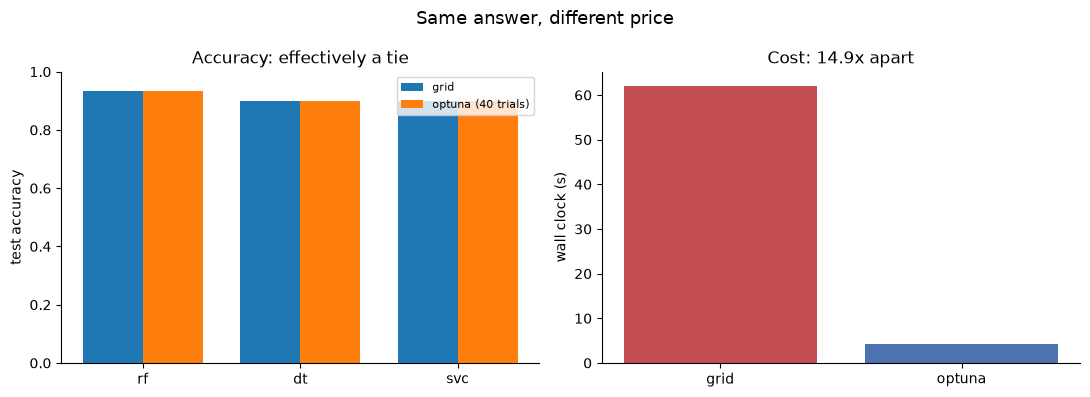

In [8]:
import matplotlib.pyplot as plt

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))

width = 0.38
positions = np.arange(len(MODELS))
for offset, (search, group) in zip((-width / 2, width / 2), comparison.groupby("search")):
    ordered = group.set_index(group["model"].str.replace("_opt", "", regex=False))
    left.bar(positions + offset, [ordered.loc[m, "accuracy"] for m in MODELS],
             width, label=search)
left.set_xticks(positions, MODELS)
left.set_ylabel("test accuracy")
left.set_ylim(0, 1)
left.set_title("Accuracy: effectively a tie")
left.legend(fontsize=8)
left.spines[["top", "right"]].set_visible(False)

right.bar(["grid", "optuna"],
          [grid_results.attrs["wall_clock"], optuna_results.attrs["wall_clock"]],
          color=["#c44e52", "#4c72b0"])
right.set_ylabel("wall clock (s)")
right.set_title(f"Cost: {speedup:.1f}x apart")
right.spines[["top", "right"]].set_visible(False)

fig.suptitle("Same answer, different price", fontsize=13)
fig.tight_layout()
plt.show()

<a id="ranges"></a>
## 5. Ranges, not just lists

This is what the grid could never do. `C: [0.1, 1, 10, 100]` can only ever propose a
power of ten. Written as a range it is sampled continuously:

```yaml
gridsearch_svc_args:
  C:      {low: 1.0e-3, high: 1.0e+2, log: true}
  gamma:  {low: 1.0e-4, high: 1.0e+0, log: true}
  kernel: ['linear', 'rbf', 'poly']    # lists and ranges mix freely
```

Integer bounds give integers (`n_estimators: {low: 10, high: 500}` never proposes 214.7),
`log: true` gives a log scale, `step: n` gives fixed spacing. Ranges need
`tuner: optuna`; under `tuner: grid` every entry must be a list, and you get an error
saying so rather than a confusing complaint from sklearn about the estimator.

In [9]:
RANGE_BLOCKS = {
    "gridsearch_svc_args": {
        "C": {"low": 1e-3, "high": 1e2, "log": True},
        "gamma": {"low": 1e-4, "high": 1e0, "log": True},
        "kernel": ["linear", "rbf", "poly"],
    },
    "gridsearch_rf_args": {
        "n_estimators": {"low": 10, "high": 300},
        "max_depth": {"low": 2, "high": 30},
        "max_features": ["sqrt", "log2"],
    },
    "gridsearch_dt_args": {
        "max_depth": {"low": 2, "high": 30},
        "criterion": ["gini", "entropy"],
    },
}

range_results = run("optuna", n_trials=40, blocks=RANGE_BLOCKS, label="optuna (ranges)")
for _, row in range_results.iterrows():
    print(f"\n{row['model']}:")
    for name, value in row["best_params"].items():
        print(f"    {name:20s} {value}")

optuna (ranges): 7.9s total

dt_opt:
    criterion            entropy
    max_depth            23

rf_opt:
    n_estimators         19
    max_features         log2
    max_depth            18

svc_opt:
    C                    0.32557386972594976
    gamma                0.3373653003947552
    kernel               linear


Look at the SVC row: values like `C = 3.7` are off the decade grid entirely. The
list-based search could not have proposed them at any budget.

In [10]:
grid_only = {"gridsearch_svc_args": RANGE_BLOCKS["gridsearch_svc_args"]}
args = {"model": ["svc"], "n_jobs": 1, "seed": 42, "grid_search": True,
        "tuner": "grid", "cross_validation": CV, **grid_only}
try:
    model_run(X_train, X_test, y_train, y_test, "demo", args)
except ValueError as error:
    print("As expected:\n")
    print(error)

As expected:

'svc' hyperparameter 'C' is written as a range ({'low': 0.001, 'high': 100.0, 'log': True}), which only the Optuna tuner can sample. Either set tuner: optuna, or write 'C' as a list of values for the grid to enumerate.


<a id="quantum"></a>
## 6. Tuning the quantum models

Quantum classifiers had no tuning path at all: to compare `encoding` or `reps` you
generated one config file per combination and diffed the runs. They now tune through
the same mechanism and the same `gridsearch_<model>_args` blocks.

Two differences from the classical path, both driven by cost — a quantum fit builds an
n-by-n fidelity kernel by circuit simulation, which is seconds rather than milliseconds:

- **It is off unless you ask twice.** `grid_search: True` *and* `tune_quantum: True`.
  Otherwise every existing config naming a quantum model would have got an order of
  magnitude slower on upgrade.
- **Each candidate is scored once**, on a stratified holdout carved out of the training
  data, rather than on k folds. `n_trials_quantum` defaults to 10, not 50.

Tuning against a **real device is refused** unless you set `allow_hardware_tuning: True`:
every trial would be a separate queued job billed to your instance, and the failure mode
is silent — the run just never appears to finish.

In [11]:
qargs = {
    "model": ["qsvc"], "n_jobs": 1, "seed": 42, "q_seed": 42,
    "backend": "simulator", "shots": 512,
    "grid_search": True, "tune_quantum": True, "n_trials_quantum": 6,
    "cross_validation": CV, "validation_split": 0.25,
    "gridsearch_qsvc_args": {
        "encoding": ["Z", "ZZ"],
        "reps": [1, 2],
        "C": {"low": 0.1, "high": 10.0, "log": True},
    },
}

# A smaller slice: the kernel is quadratic in the number of training samples.
Xq_train, Xq_test = X_train[:45], X_test[:15]
yq_train, yq_test = y_train[:45], y_test[:15]

t0 = time.time()
qout = model_run(Xq_train, Xq_test, yq_train, yq_test, "demo", qargs)
qmetrics = qout["results_qsvc_opt"][0]

print(f"\nQSVC tuned in {time.time() - t0:.0f}s")
print(f"accuracy: {qmetrics['accuracy']:.3f}")
print("chosen:")
for name, value in tuned_params(qmetrics).items():
    print(f"    {name:18s} {value}")

Currently running a quantum support vector classifier (QSVC) on this dataset.
The number of qubits in your circuit is: 5
The number of parameters in your circuit is: 5



QSVC tuned in 14s
accuracy: 0.667
chosen:
    feature_map        ZZFeatureMap
    quantum_kernel     FidelityQuantumKernel
    C                  0.23270677083837804
    gamma              scale
    encoding           ZZ
    reps               1


The reported parameters are the base function's circuit description with the tuned
values laid over it — you get both the `ZZFeatureMap` that was built and the `encoding`
and `reps` that produced it. The reported `time` covers the whole search, not just the
final fit.

For comparison, the same model at its default hyperparameters:

In [12]:
baseline_args = {k: v for k, v in qargs.items() if k not in ("tune_quantum", "grid_search")}
baseline_args.update({"grid_search": False, "qsvc_args": {"encoding": "ZZ", "reps": 2}})

t0 = time.time()
bout = model_run(Xq_train, Xq_test, yq_train, yq_test, "demo", baseline_args)
bmetrics = bout["results_qsvc"][0]
print(f"untuned QSVC: {time.time() - t0:.0f}s, accuracy {bmetrics['accuracy']:.3f}")
print(f"tuned   QSVC: accuracy {qmetrics['accuracy']:.3f} "
      f"(6 trials, so ~6x the cost of one run)")

Currently running a quantum support vector classifier (QSVC) on this dataset.
The number of qubits in your circuit is: 5
The number of parameters in your circuit is: 5


untuned QSVC: 4s, accuracy 0.867
tuned   QSVC: accuracy 0.667 (6 trials, so ~6x the cost of one run)


### The tuned model scored *worse*. That is the lesson, not a bug.

On the committed run the tuned QSVC reaches 0.667 against the default's 0.867. Worth
sitting with rather than explaining away, because it is the most useful thing in this
section.

Each candidate here is scored on a stratified holdout carved out of 45 training rows at
`validation_split: 0.25` — about **11 validation samples**. Selecting the best of six
configurations on 11 samples is largely selecting noise: one sample is 9 percentage points,
so the winner is whichever config got the friendlier eleven rows, and that advantage does
not transfer to the test set. The search did exactly what it was asked to do; what it was
asked to do was not informative.

This is not specific to quantum models — it is what any tuner does on too little
validation data — but the quantum path runs into it sooner, because the cheap single
holdout is what makes a quantum search affordable at all.

**What to do about it, in order of preference:**

- **More data.** The inner split has to be big enough that a difference between two
  configurations outruns sampling noise. This is the real fix.
- **Raise `validation_split`** (say 0.4) so the score is steadier — at the cost of
  training each candidate on less.
- **Spend fewer trials.** Counter-intuitive, but more trials on a noisy objective means
  more opportunity to find a spuriously good one; the winner's optimism grows with the
  number of candidates.
- **Sanity-check against the untuned baseline**, as this notebook does. If tuning loses
  to the default, trust the default and treat the tuning result as uninformative.

The classical comparison in sections 2–4 does not have this problem: it scores on 3-fold
cross-validation over 90 training rows, so every candidate is judged on all of them.

Where quantum tuning does earn its keep is when you genuinely do not know which encoding
suits your data *and* you have the samples to tell. Comparing `Z` against `ZZ` at two
`reps` used to mean writing four config files and diffing four runs; it is now one block
and one run.

<a id="takeaways"></a>
## 7. Takeaways

- **`tuner: optuna` is the default** and reaches a comparable answer for a small
  fraction of the exhaustive sweep's cost. The saving grows with the size of the block:
  a bigger grid costs the sweep proportionally more and costs Optuna nothing extra,
  because `n_trials` is fixed.
- **Existing configs keep working unchanged.** A list still means a categorical choice.
- **Ranges are the reason to edit a config**: `{low, high, log}` searches values a list
  of decades cannot express.
- **`tuner: grid` is still there** for reproducing a number published against the
  exhaustive search.
- **A tuned model can lose to the default when the validation split is tiny.**
  Tuning selects on the inner split; if that split is too small to resolve a real
  difference, it selects noise. Always compare against the untuned baseline.
- **Quantum tuning needs two keys** (`grid_search` and `tune_quantum`) and its own
  smaller budget (`n_trials_quantum`), because each trial is a quantum fit.
- **Budget beats grid size.** With Optuna you no longer trim a block to control runtime;
  you widen the block and set `n_trials`. Those are independent knobs now.

### Where these keys live

```yaml
grid_search: True        # tune at all
tuner: optuna            # 'optuna' (default) or 'grid'
n_trials: 50             # classical budget per model
cross_validation: 5      # folds used to score a classical candidate

tune_quantum: False      # also tune qsvc/vqc/qnn/pqk/qpl
n_trials_quantum: 10     # their (smaller) budget
validation_split: 0.25   # holdout fraction used to score a quantum candidate
```

### See also

- `tutorial/CatBoost_and_TabPFN/catboost_and_tabpfn.ipynb` — the two classical learners
  added after this notebook was written. Both tune through the same blocks and both engines
  shown here, so nothing above changes; but CatBoost brings one hyperparameter conflict
  worth knowing about (`subsample` and `bagging_temperature` belong to incompatible
  bootstrap schemes) and one that is silently inert at the default grow policy
  (`min_data_in_leaf`). TabPFN is the odd case: it is pretrained, so what its
  `gridsearch_tabpfn_args` block searches are *inference* settings rather than capacity —
  a trial there costs `cross_validation` transformer forward passes, not five cheap fits.
